# Salary Prediction : Regression Analysis

**Project Description**
Predicting employee salaries based on different features using Linear Regression

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import re
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
df= pd.read_csv('Salary_Data.csv')

In [4]:
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [5]:
df.shape

(6704, 6)

**Data Cleaning**

In [6]:
df= df.dropna()

In [7]:
df.shape

(6698, 6)

# Bivariate Linear Regression

## **Extracting the relevant colums**

In [8]:
reg = df[['Years of Experience', 'Salary']].copy()

In [9]:
reg.head()

,Years of Experience,Salary
0,5.0,90000.0
1,3.0,65000.0
2,15.0,150000.0
3,7.0,60000.0
4,20.0,200000.0


In [10]:
reg.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6698 entries, 0 to 6703
Data columns (total 2 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Years of Experience  6698 non-null   float64
 1   Salary               6698 non-null   float64
dtypes: float64(2)
memory usage: 157.0 KB


In [11]:
reg.describe()

,Years of Experience,Salary
count,6698.000000,6698.000000
mean,8.095178,115329.253061
std,6.060291,52789.792507
min,0.000000,350.000000
25%,3.000000,70000.000000
50%,7.000000,115000.000000
75%,12.000000,160000.000000
max,34.000000,250000.000000


**Understading the correlation between variables**

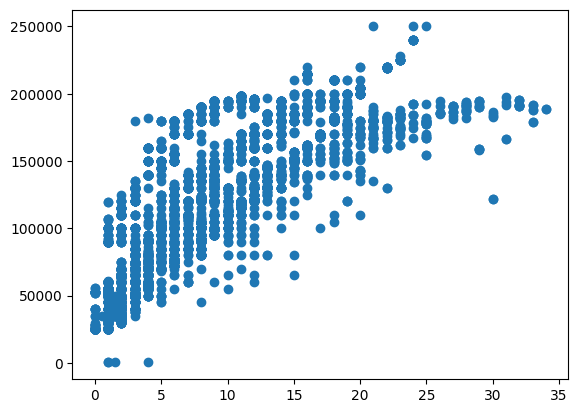

In [12]:
plt.scatter(reg['Years of Experience'], reg['Salary'])

In [14]:
#correlation
reg.corr()

,Years of Experience,Salary
Years of Experience,1.000000,0.808968
Salary,0.808968,1.000000


These 2 variables are strongly correlated so we can perform a meaningful regression analysis.

**Independent and Dependent variables**

In [15]:
X = reg[['Years of Experience']] #Independent feature
y = reg['Salary'] #Dependent feature

**Train Test Split**

In [16]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)

In [17]:
X_train.shape

(5358, 1)

**Applying Simple Linear Regression**

In [18]:
regression=LinearRegression()
regression.fit(X_train, y_train)

LinearRegression()

In [19]:
regression.coef_

array([7072.86168671])

In [20]:
regression.intercept_

np.float64(58196.21064922571)

**Plotting training data best fit line**

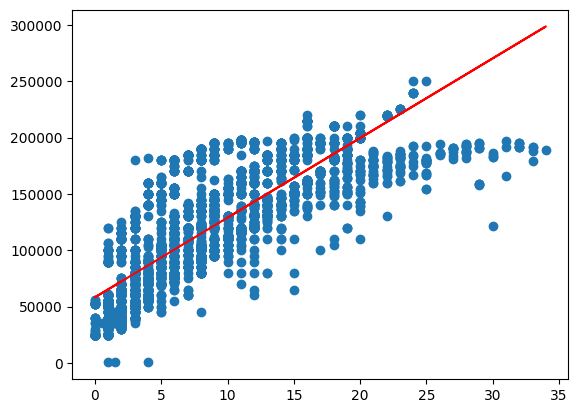

In [21]:
plt.scatter(X_train, y_train)
plt.plot(X_train, regression.predict(X_train), color='red')

**Prediction for test data**

In [22]:
y_test_pred= regression.predict(X_test)

**Model Evaluation**

In [23]:
y_train_pred = regression.predict(X_train)

*Test performance*

In [24]:
#Measuring the average absolute difference between actual and predicted values.
mae_test = mean_absolute_error(y_test, y_test_pred)

In [25]:
#MSE Squares the errors → penalizes larger errors more heavily.
mse_test = mean_squared_error(y_test, y_test_pred)

In [26]:
#The square root of MSE → back to original units
rmse_test = np.sqrt(mse_test)

In [27]:
#R² Score (Coefficient of Determination): Explains how much variance in y is explained by the model
r2_test = r2_score(y_test, y_test_pred)

*Train performance*

In [28]:
mae_train = mean_absolute_error(y_train, y_train_pred)
mse_train = mean_squared_error(y_train, y_train_pred)
rmse_train = np.sqrt(mse_train)
r2_train = r2_score(y_train, y_train_pred)

*Comparaison*

In [29]:
results = pd.DataFrame({
    "MAE": [mae_train, mae_test],
    "MSE": [mse_train, mse_test],
    "RMSE": [rmse_train, rmse_test],
    "R2": [r2_train, r2_test]
}, index=["Train 0.8%", "Test 0.2%"])

results_rounded = results.round({
    "MAE": 2,
    "MSE": 0,     # Rounding to the nearest whole number
    "RMSE": 2,
    "R2": 3
})

results_rounded

,MAE,MSE,RMSE,R2
Train 0.8%,24835.31,958134740.0,30953.75,0.654
Test 0.2%,25054.11,982050062.0,31337.68,0.656


Interpretations:

1. R2 tran and R2 test are almost identical --> our model is robust
2. our model(years of experience explains 65% of the variation in salary; This confirms that Experience is important, but it's not the whole story.

--> This bivariate linear regression is too simple of a model to capture the complexity of real word salaries: We need MULTIVRIATE Regression.

In [30]:
X_range = np.linspace(
    reg['Years of Experience'].min(),
    reg['Years of Experience'].max(),
    100
).reshape(-1, 1)

In [31]:
X_range_df = pd.DataFrame(X_range, columns=['Years of Experience'])

Y_pred = regression.predict(X_range_df)

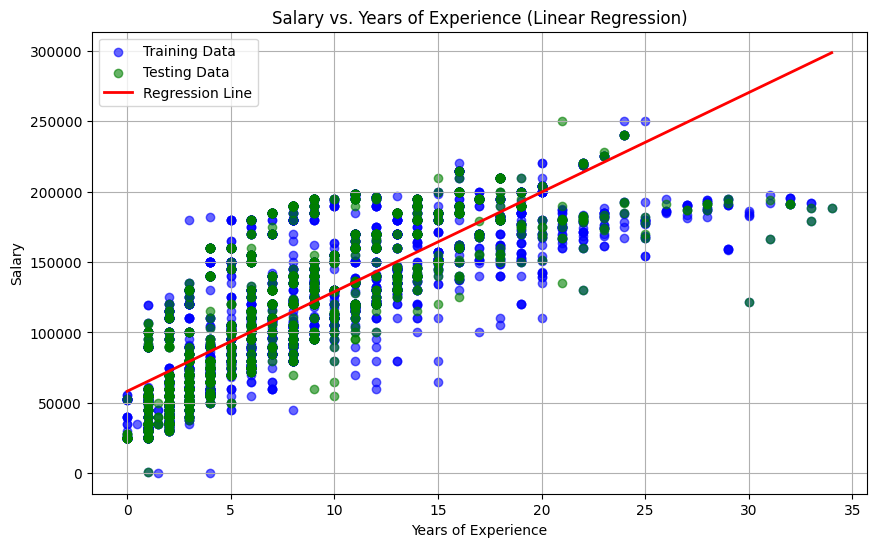

In [32]:
plt.figure(figsize=(10, 6))


plt.scatter(
    X_train, y_train, color='blue', label='Training Data', alpha=0.6
)


plt.scatter(
    X_test, y_test, color='green', label='Testing Data', alpha=0.6
)


plt.plot(
    X_range_df, Y_pred, color='red',
    linewidth=2,
    label=f'Regression Line'
)

# Add Titles and Labels
plt.title('Salary vs. Years of Experience (Linear Regression)')
plt.xlabel('Years of Experience')
plt.grid(True)
plt.ylabel('Salary')
plt.legend()


# Multivariate Linear Regression

**Studying correlation between different variables**

In [33]:
df['Gender'].unique()

array(['Male', 'Female', 'Other'], dtype=object)

In [34]:
df['Education Level'].unique()

array(["Bachelor's", "Master's", 'PhD', "Bachelor's Degree",
       "Master's Degree", 'High School', 'phD'], dtype=object)

1. Data Normalization before pre-processing

In [35]:
df['Education Level'] = (
    df['Education Level']
    .astype(str)
    .str.lower()
    .str.replace(r"[^\w\s]", "", regex=True) # Removes apostrophes, commas, etc.
    .str.replace(" degree", "", regex=False) # Removes the word ' degree'
    .str.strip() # Removes extra whitespace
)

In [36]:
df['Education Level'] = df['Education Level'].replace({
    'bachelors': 'Bachelors',
    'masters': 'Masters',
    'phd': 'PhD',
    'high school': 'High School'
})

2. Preprocessing: One-Hot Encoding Categorical Variables

In [37]:
df_encoded = pd.get_dummies(df, columns=['Gender', 'Education Level'], drop_first=True)
df_encoded = df_encoded.drop(columns=['Job Title'], errors='ignore')

3. Calculate the Full Correlation Matrix

In [38]:
correlation_matrix = df_encoded.corr()
mask = np.triu(correlation_matrix)

4. Visualizing the heatmap

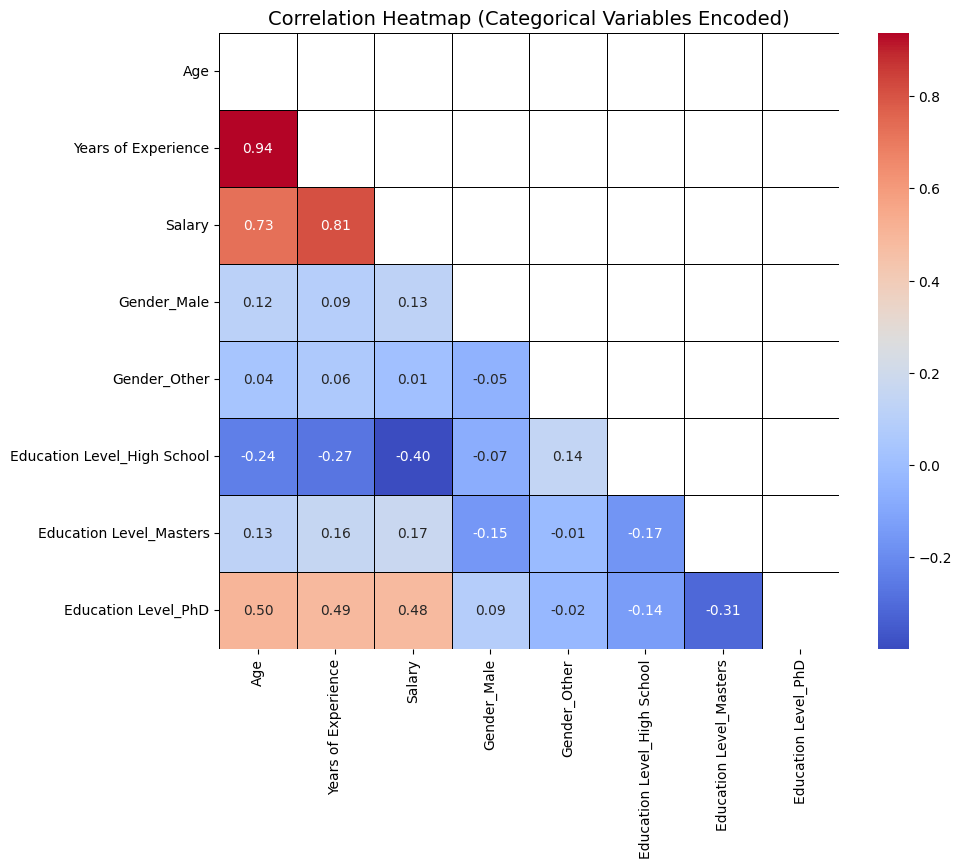

In [39]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    cbar=True,
    linewidths=0.5,
    linecolor='black',
)
plt.title('Correlation Heatmap (Categorical Variables Encoded)', fontsize=14)
plt.show()

5. Interpretations



*   Age and years of experience are highly correlated(r=0.94) --> we have a case of multicollinearity.
* Years of experience correlates better with salary than age --> Years of experience is a better feature to keep, and we drop age to avoid problems related t multicollinearity.

  


**Multivariate Regression Analysis**

In [40]:
# 1. Defining Features: dropping 'Age' and 'Salary' (Target)
X = df_encoded.drop(columns=['Salary', 'Age'])
y = df_encoded['Salary']

In [41]:
# 2. Training the Model
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [44]:
# 3. Evaluating our Model's Performance
y_pred = model.predict(X_test)

print(f"Model Accuracy (R2): {r2_score(y_test, y_pred):.2f}")
print(f"Average Error (MAE): {mean_absolute_error(y_test, y_pred):.2f}")

Model Accuracy (R2): 0.71
Average Error (MAE): 22700.93


*Model Performance Interpretation:*


*   This model explains 71% of the variation in salary. While not perfect, it's better than the bivariate model result.
*  On average, the model's predictions are off by about $22,700. This suggests there are still unobserved factors influencing salary that this dataset doesn't capture.


In [43]:
# 4. Viewing Feature Importance
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient (Dollars)': model.coef_
}).sort_values(by='Coefficient (Dollars)', ascending=False)

print("\nFeature Coefficients:")
print(importance_df)


Feature Coefficients:
                       Feature  Coefficient (Dollars)
5          Education Level_PhD           21449.326918
4      Education Level_Masters           11387.700565
0          Years of Experience            5759.396313
1                  Gender_Male            4817.030734
2                 Gender_Other             861.348421
3  Education Level_High School          -37545.733782


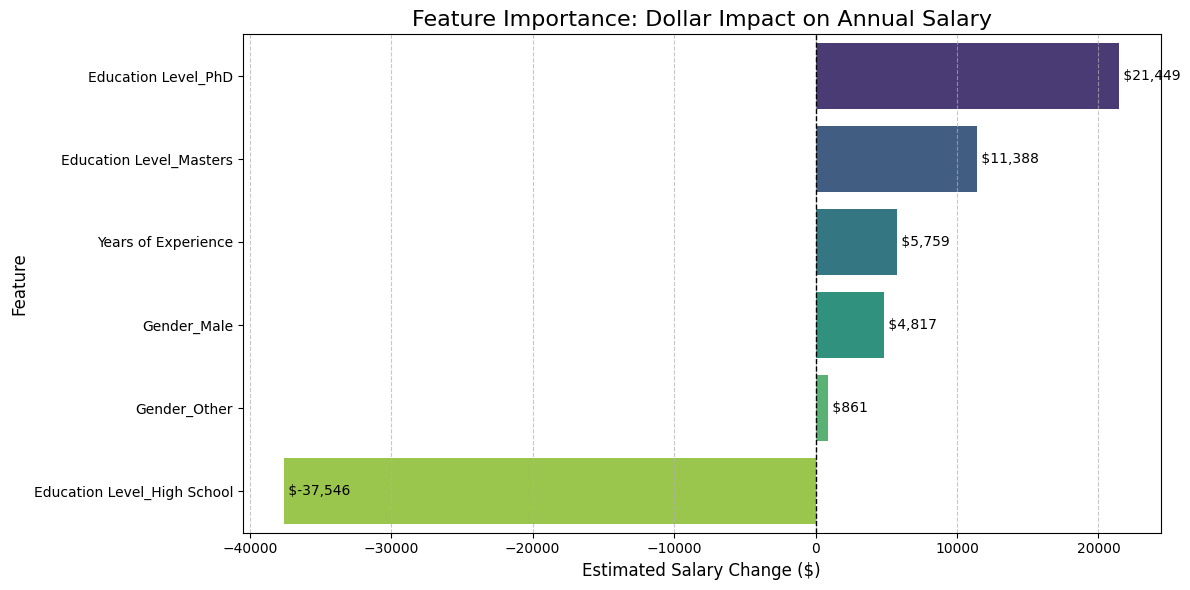

In [46]:
# 5. Visualizing feature importance

#Prearing the dataframe from our data and sorting it
data = {
    'Feature': [
        'Education Level_PhD',
        'Education Level_Masters',
        'Years of Experience',
        'Gender_Male',
        'Gender_Other',
        'Education Level_High School'
    ],
    'Coefficient': [
        21449.33,
        11387.70,
        5759.40,
        4817.03,
        861.35,
        -37545.73
    ]
}

df_coeffs = pd.DataFrame(data).sort_values(by='Coefficient', ascending=False)

#Plotting the Bar Chart
plt.figure(figsize=(12, 6))

sns.barplot(
    data=df_coeffs,
    x='Coefficient',
    y='Feature',
    hue= 'Feature',
    palette='viridis'  # Color scheme (Green/Blue/Purple)
)

plt.title('Feature Importance: Dollar Impact on Annual Salary', fontsize=16)
plt.xlabel('Estimated Salary Change ($)', fontsize=12)
plt.ylabel('Feature', fontsize=12)

# Adding a vertical line at 0 to distinguish positive/negative impacts
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)

for index, value in enumerate(df_coeffs['Coefficient']):
    plt.text(
        value,
        index,
        f' ${value:,.0f}',
        va='center'
    )

plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()